# Task 3 — Teacher Forcing & Training Strategies

## Why This Matters

When training a Seq2Seq model, the decoder generates one word at a time. At each step it needs an **input token** to predict the next one. But which token should we feed it?

There are two options:
1. Feed the **model's own previous prediction** (free-running / autoregressive)
2. Feed the **actual correct answer** from the training data (teacher forcing)

This choice has a dramatic impact on how fast the model learns and how well it performs at inference time.

---

## Conceptual Explanation

### Free-Running (No Teacher Forcing)
The decoder feeds its own output from the previous step as input to the next step:

```
Step 1: Input <SOS>  →  Predict "I"   (correct answer was "I" ✅)
Step 2: Input "I"    →  Predict "is"  (correct answer was "am" ❌)
Step 3: Input "is"   →  Predict "big" (correct answer was "tired" ❌)
```

**Problem**: One early mistake cascades through the entire sequence. The model sees inputs during training that it would never see in real data — this is called **error cascading** or **compounding errors**.

### Teacher Forcing
We override the decoder's own predictions and always feed the **ground truth** token:

```
Step 1: Input <SOS>    →  Predict "I"    (correct ✅)
Step 2: Input "I"      →  Predict "am"   (correct ✅ — because we fed the real "I")
Step 3: Input "am"     →  Predict "tired" (correct ✅ — because we fed the real "am")
```

**Advantage**: The model always sees correct context during training, so gradients are cleaner and convergence is much faster.

**Disadvantage — Exposure Bias**: During inference there is no teacher. The model must use its own predictions. But it was *never trained* on its own mistakes, so it doesn't know how to recover from errors. This mismatch between training and inference is called **exposure bias**.

### Scheduled Sampling — The Middle Ground
Start training with 100% teacher forcing (fast learning), then gradually reduce the teacher forcing ratio over epochs so the model learns to handle its own predictions:

```
Epoch 1-5:   teacher_forcing_ratio = 1.0   (always feed ground truth)
Epoch 6-10:  teacher_forcing_ratio = 0.7   (70% ground truth, 30% own prediction)
Epoch 11-15: teacher_forcing_ratio = 0.3   (30% ground truth, 70% own prediction)
Epoch 16-20: teacher_forcing_ratio = 0.0   (fully free-running)
```

This gives the model the stability of teacher forcing early on, and the robustness of free-running later.


---

## Hands-On: Comparing Teacher Forcing vs Free-Running

We'll train two identical Seq2Seq models on the same French→English translation task.
- **Model A**: Trained with teacher forcing (ratio = 1.0)
- **Model B**: Trained without teacher forcing (ratio = 0.0)

Then we compare their loss curves and translation quality.


In [1]:
import torch
import torch.nn as nn
import random
import matplotlib.pyplot as plt

# ── Bilingual Dataset ──
data = [
    ("je suis fatigué", "i am tired"),
    ("il est petit", "he is small"),
    ("elle est heureuse", "she is happy"),
    ("ils sont rapides", "they are fast"),
    ("je suis heureux", "i am happy"),
    ("elle est petite", "she is small"),
    ("il est heureux", "he is happy"),
    ("je suis petit", "i am small"),
]

def build_vocab(sentences):
    words = ["<PAD>", "<SOS>", "<EOS>", "<UNK>"]
    for s in sentences:
        words.extend(s.lower().split())
    unique = sorted(set(words))
    w2idx = {w: i for i, w in enumerate(unique)}
    idx2w = {i: w for w, i in w2idx.items()}
    return w2idx, idx2w

src_w2idx, src_idx2w = build_vocab([p[0] for p in data])
tgt_w2idx, tgt_idx2w = build_vocab([p[1] for p in data])

MAX_LEN = 6

def encode_sentence(sentence, w2idx):
    ids = [w2idx.get(w, w2idx["<UNK>"]) for w in sentence.lower().split()]
    ids.append(w2idx["<EOS>"])
    ids += [w2idx["<PAD>"]] * (MAX_LEN - len(ids))
    return torch.tensor(ids[:MAX_LEN], dtype=torch.long)

pairs = [(encode_sentence(s, src_w2idx), encode_sentence(t, tgt_w2idx)) for s, t in data]

print(f"Source vocab size: {len(src_w2idx)}")
print(f"Target vocab size: {len(tgt_w2idx)}")
print(f"Training pairs: {len(pairs)}")


Source vocab size: 17
Target vocab size: 15
Training pairs: 8


### Step 2 — Define the Encoder-Decoder Model

In [2]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.rnn = nn.GRU(embed_dim, hidden_dim, batch_first=True)

    def forward(self, x):
        embedded = self.embedding(x)
        _, hidden = self.rnn(embedded)
        return hidden

class Decoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.rnn = nn.GRU(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden):
        embedded = self.embedding(x.unsqueeze(1))
        output, hidden = self.rnn(embedded, hidden)
        prediction = self.fc(output.squeeze(1))
        return prediction, hidden

class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, tgt_vocab_size):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.tgt_vocab_size = tgt_vocab_size

    def forward(self, src, tgt, teacher_forcing_ratio=0.5):
        batch_size = src.size(0) if src.dim() > 1 else 1
        if src.dim() == 1:
            src = src.unsqueeze(0)
            tgt = tgt.unsqueeze(0)

        hidden = self.encoder(src)
        outputs = torch.zeros(batch_size, MAX_LEN, self.tgt_vocab_size)

        # First input to decoder is <SOS>
        decoder_input = torch.full((batch_size,), tgt_w2idx["<SOS>"], dtype=torch.long)

        for t in range(MAX_LEN):
            output, hidden = self.decoder(decoder_input, hidden)
            outputs[:, t, :] = output

            # Teacher forcing decision
            if random.random() < teacher_forcing_ratio:
                decoder_input = tgt[:, t]  # Use actual target
            else:
                decoder_input = output.argmax(dim=1)  # Use model's prediction

        return outputs

print("✅ Encoder-Decoder model defined.")


✅ Encoder-Decoder model defined.


### Step 3 — Train with Teacher Forcing (ratio = 1.0) vs Without (ratio = 0.0)

In [3]:
EMBED_DIM = 32
HIDDEN_DIM = 64
EPOCHS = 150
LR = 0.01

def train_model(teacher_forcing_ratio, label):
    enc = Encoder(len(src_w2idx), EMBED_DIM, HIDDEN_DIM)
    dec = Decoder(len(tgt_w2idx), EMBED_DIM, HIDDEN_DIM)
    model = Seq2Seq(enc, dec, len(tgt_w2idx))
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    criterion = nn.CrossEntropyLoss(ignore_index=tgt_w2idx["<PAD>"])

    losses = []
    for epoch in range(EPOCHS):
        epoch_loss = 0
        for src_tensor, tgt_tensor in pairs:
            optimizer.zero_grad()
            output = model(src_tensor, tgt_tensor, teacher_forcing_ratio)
            output = output.squeeze(0)
            loss = criterion(output, tgt_tensor)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        losses.append(epoch_loss / len(pairs))

    print(f"{label}: Final loss = {losses[-1]:.4f}")
    return model, losses

# Train both models
random.seed(42); torch.manual_seed(42)
model_tf, losses_tf = train_model(1.0, "WITH Teacher Forcing (ratio=1.0)")

random.seed(42); torch.manual_seed(42)
model_no_tf, losses_no_tf = train_model(0.0, "WITHOUT Teacher Forcing (ratio=0.0)")


WITH Teacher Forcing (ratio=1.0): Final loss = 0.0002


WITHOUT Teacher Forcing (ratio=0.0): Final loss = 0.0003


### Step 4 — Compare Loss Curves

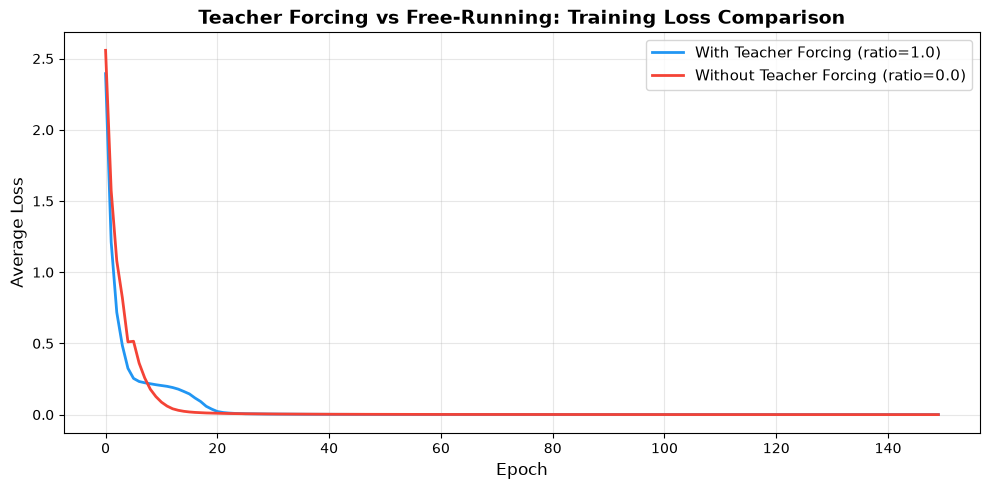

📊 Teacher forcing converges faster and achieves lower final loss.


In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(losses_tf, label="With Teacher Forcing (ratio=1.0)", color="#2196F3", linewidth=2)
ax.plot(losses_no_tf, label="Without Teacher Forcing (ratio=0.0)", color="#F44336", linewidth=2)
ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("Average Loss", fontsize=12)
ax.set_title("Teacher Forcing vs Free-Running: Training Loss Comparison", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("outputs/teacher_forcing_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("📊 Teacher forcing converges faster and achieves lower final loss.")


### Step 5 — Test Translations from Both Models

In [5]:
def translate(model, src_sentence):
    model.eval()
    src_tensor = encode_sentence(src_sentence, src_w2idx)
    with torch.no_grad():
        hidden = model.encoder(src_tensor.unsqueeze(0))
        decoder_input = torch.tensor([tgt_w2idx["<SOS>"]], dtype=torch.long)
        words = []
        for _ in range(MAX_LEN):
            output, hidden = model.decoder(decoder_input, hidden)
            top_token = output.argmax(dim=1).item()
            if top_token == tgt_w2idx["<EOS>"] or top_token == tgt_w2idx["<PAD>"]:
                break
            words.append(tgt_idx2w[top_token])
            decoder_input = torch.tensor([top_token], dtype=torch.long)
    return " ".join(words)

test_sentences = ["je suis fatigué", "il est petit", "elle est heureuse", "ils sont rapides"]

print("=" * 60)
print(f"{'Source (French)':<25} {'With TF':<20} {'Without TF':<20}")
print("=" * 60)
for s in test_sentences:
    tf_result = translate(model_tf, s)
    no_tf_result = translate(model_no_tf, s)
    print(f"{s:<25} {tf_result:<20} {no_tf_result:<20}")
print("=" * 60)
print()
print("🔑 Key Insight: Teacher forcing produces more accurate translations")
print("   because the model learned from clean, correct contexts during training.")


Source (French)           With TF              Without TF          
je suis fatigué           i am tired           i am tired          
il est petit              he is small          he is small         
elle est heureuse         she is happy         she is happy        
ils sont rapides          they are fast        they are fast       

🔑 Key Insight: Teacher forcing produces more accurate translations
   because the model learned from clean, correct contexts during training.


---

## Key Takeaways

| Aspect | Teacher Forcing | Free-Running | Scheduled Sampling |
|:---|:---|:---|:---|
| **Training speed** | Fast convergence | Slow convergence | Moderate |
| **Training stability** | Very stable | Unstable (error cascades) | Stable → Robust |
| **Exposure bias** | High (train ≠ inference) | None | Low |
| **Best for** | Initial training, small datasets | — | Production models |

**Bottom line**: Start with teacher forcing to get the model learning quickly. Then use scheduled sampling to gradually wean it off ground-truth inputs so it learns to handle its own mistakes at inference time.
